In [1]:
import sympy as syp
import numpy as np
import numba as nb
from sympy import N as expr2f
from IPython.display import Math, display
from scipy.integrate import dblquad
from scipy.integrate import nquad
from scipy.special import spence
from timeit import default_timer as timer
import matplotlib.pyplot as plt

import Bonds
import SpinWave as SW

In [2]:
## declare symbolic variables

h, J, K, G, Gp, J3, th_H, phi_H, g = syp.symbols('h, J, K, G, Gp, J3, th_H, phi_H, g', real=True); 
alpha, beta = syp.symbols('alpha, beta', real=True); 

t1, p1, t2, p2, t3, p3, t4, p4, t5, p5, t6, p6, t7, p7, t8, p8, t9, p9, t10, p10, t11, p11, t12, p12 = syp.symbols('t_1, p_1, t_2, p_2, t_3, p_3, t_4, p_4, t_5, p_5, t_6, p_6, t_7, p_7, t_8, p_8, t_9, p_9, t_10, p_10, t_11, p_11, t_12, p_12', real=True);
h1, g1, h2, g2, h3, g3, h4, g4, h5, g5, h6, g6, h7, g7, h8, g8, h9, g9, h10, g10, h11, g11, h12, g12 = syp.symbols('h_1, g_1, h_2, g_2, h_3, g_3, h_4, g_4, h_5, g_5, h_6, g_6, h_7, g_7, h_8, g_8, h_9, g_9, h_10, g_10, h_11, g_11, h_12, g_12', real=True);


# First example: spin wave Hamiltonian for the extended Kitaev model with the zigzag order


$$
\mathcal{H} = \sum_{\langle ij\rangle\in\alpha\beta(\gamma)} \Big[ J \boldsymbol{S}_{i}\cdot \boldsymbol{S}_{j}+KS_{i}^{\gamma}S_{j}^{\gamma}+\Gamma(S_{i}^{\alpha}S_{j}^{\beta}+S_{i}^{\beta}S_{j}^{\alpha}) 
+\Gamma^\prime (S_{i}^{\alpha}S_{j}^{\gamma}+S_{i}^{\gamma}S_{j}^{\alpha}+S_{i}^{\beta}S_{j}^{\gamma}+S_{i}^{\gamma}S_{j}^{\beta})
\Big]
+\sum_{\langle\langle\langle ij\rangle\rangle\rangle} J_3 \boldsymbol{S}_{i}\cdot \boldsymbol{S}_{j}
$$

It's convenient to define the C3 transformation matrix between the x,y,z bond-dependent interactions.
For real material, the interactions are defined in the local octahedral xyz axes. we also define the transformation that rotates to the crystallographic abc axes.

In [3]:
th_vec = syp.acos(1/syp.sqrt((3)));
abc = syp.Matrix([[syp.sin(th_vec)*syp.cos(-syp.pi/3), syp.sin(th_vec)*syp.sin(-syp.pi/3), syp.cos(th_vec)],
               [syp.sin(th_vec)*syp.cos(syp.pi/3), syp.sin(th_vec)*syp.sin(syp.pi/3), syp.cos(th_vec)],
               [syp.sin(th_vec)*syp.cos(syp.pi), syp.sin(th_vec)*syp.sin((syp.pi)), syp.cos(th_vec)]]);

C3 = abc.T@np.array([[0, 1, 0],
         [0, 0, 1],
         [1, 0, 0]])@abc

Jpp = syp.Integer(1)/3*K + syp.Integer(2)/3*(G-Gp);
Jcp = syp.Integer(1)/3*K - syp.Integer(1)/3*(G-Gp);
Jab = J - Gp +Jcp;
Jc = (J + 2*Gp + Jpp);

Dz = syp.Matrix([[Jab+Jpp, 0, -syp.sqrt(2)*Jcp],
    [0, Jab-Jpp, 0],
    [-syp.sqrt(2)*Jcp,    0, Jc]]);

## you can also use 
# Dz = abc.T@np.array([[J,G,Gp],
#                    [G,J,Gp],
#                    [Gp,Gp,J+K]])@abc

Dx = syp.expand(C3.T@Dz@C3);
Dy = syp.expand(C3.T@C3.T@Dz@C3@C3);


Next, define the displacement vectors and the interactions matrix for each type of bonds. Put them into two lists.
For example, the x-bond has the displacement $\delta_x$ and the interaction $D_x$. You can add any interactions (further neighbour and interlayer ones) following this format.

In [4]:
display(Bonds.delta_x, Dx)

Matrix([
[      1/2],
[sqrt(3)/6],
[        0]])

Matrix([
[                  -2*G/3 - Gp/3 + J + K/6, -sqrt(3)*G/3 + sqrt(3)*Gp/3 - sqrt(3)*K/6, -sqrt(2)*G/6 + sqrt(2)*Gp/6 + sqrt(2)*K/6],
[-sqrt(3)*G/3 + sqrt(3)*Gp/3 - sqrt(3)*K/6,                             -Gp + J + K/2,  sqrt(6)*G/6 - sqrt(6)*Gp/6 - sqrt(6)*K/6],
[-sqrt(2)*G/6 + sqrt(2)*Gp/6 + sqrt(2)*K/6,  sqrt(6)*G/6 - sqrt(6)*Gp/6 - sqrt(6)*K/6,                  2*G/3 + 4*Gp/3 + J + K/3]])

In [5]:
bond_vecs = [Bonds.delta_x, Bonds.delta_y, Bonds.delta_z, 
             (Bonds.a1+Bonds.a2)*2/3, (Bonds.a1-2*Bonds.a2)*2/3, (Bonds.a2-2*Bonds.a1)*2/3]
bond_Js = [Dx, Dy, Dz, J3*syp.eye(3), J3*syp.eye(3), J3*syp.eye(3)]

Next, define the moment directions and real-space positions for each site of the magnetic order. The directions are written in the crystallographic abc axis, same as the interaction matrices.

In [6]:
N = 4; # the zigzag order has 4 site in the magnetic unit cell

## magnetic unit cell vectors
v1 = syp.Matrix([1,0,0]);
v2 = 2*syp.Matrix([syp.Integer(1)/syp.Integer(2),syp.sqrt(3)/2,0]);
v3 = syp.Matrix([0, 0, syp.Integer(1)]);

## spin directions (spin_theta, spin_phi, orb_theta, orb_phi) on each site
## can use symbols or numerical values
spin = syp.zeros(N,2); 
spin[0,0] = t1; spin[0,1] = p1; 
spin[1,0] = t1; spin[1,1] = p1; 
spin[2,0] = t2; spin[2,1] = p2; 
spin[3,0] = t2; spin[3,1] = p2;

## position of each site in the magnetic unit cell. 
atom_pos = syp.zeros(N,3);
atom_pos[0,:] = syp.zeros(1,3);
atom_pos[1,:] = Bonds.delta_x.T;
atom_pos[2,:] = Bonds.delta_x.T-Bonds.delta_z.T;
atom_pos[3,:] = 2*Bonds.delta_x.T-Bonds.delta_z.T;

Only the relative positions are important, as they will be matched with the bonds' displacement vectors to idenfity all the bonds in the magnetic unit cell.

Then, we can determine the symbolic spin wave Hamiltonian

In [7]:
start = timer();

## calculate all the bonds
bonds = Bonds.findBonds(atom_pos, v1,v2,v3, bond_vecs);
print("Bonds. time: ", timer()-start);

## add the external magnetic field term
hv = h*g*syp.Matrix([syp.sin(th_H)*syp.cos(phi_H), syp.sin(th_H)*syp.sin(phi_H), syp.cos(th_H)])

## get the symbolic Hamiltonian
H4, E4 = SW.spin_Hamiltonian(spin, bonds, bond_Js, hv)
print("Hamiltonian. time: ", timer()-start);

Bonds. time:  3.2619578999001533
Hamiltonian. time:  36.08273739996366


Symbolic calculations are slow, but we only need to calculate once. For complex models or large magnetic orders, we can save the symbolic results to a file. 
In the case that we know what magnetic order we are working on, we can significantly speed up the symbolic calculations by reducing the number of variables in the spin directions. For example, we know the zigzag order has two chains of parallel spins, so spin 1 and spin 2 are the same, and  spin 3 and spin 4 are the same. We can further set the p1 and p2 to be zero for the case we will study below where the spin are all in the $ac$ plane 

Next, we can substitute in numerical values. For the spin directions, we solve for those that minimize the classical zigzag order energy. We already assume the spins are in the $ac$ plane, which are found using classical Monte Carlo simulations (CMC).
In general, we use CMC to find the spin directions for complex magnetic orders, 

In [8]:
## calculate spin directions of the model. can change to numerical root-finding for speed
## substitute in the numerical spin directions
Sv = syp.Matrix([syp.sin(t1)*syp.cos(p1), syp.sin(t1)*syp.sin(p1), syp.cos(t1)]);
Ezz = (2*((-Sv.T)@Dz@Sv + Sv.T@Dx@Sv + Sv.T@Dy@Sv) + (6*J3)*Sv.T@syp.eye(3)@Sv)[0];
Ezz = syp.simplify(Ezz.subs([(p1, 0)]));
ZZsoln = syp.solve(syp.diff(Ezz, t1), t1);
def getZZangle_exact(J_num, K_num, G_num, Gp_num, J3_num):
    
    thzz = (expr2f(ZZsoln[0].subs([(J,J_num),(K,K_num),(G,G_num),(Gp,Gp_num),(J3, J3_num)])));
    if thzz < 0 and thzz > -1/2*np.pi:
        thzz += np.pi/2;
    if thzz < -1/2*np.pi and thzz > -np.pi:
        thzz += np.pi;
        
    # r = -G_num/(K_num+Gp_num)
    # thzz = np.pi/2 - 0.5*np.arctan(4*np.sqrt(2)*(1+r)/(7*r-2))

    # print(thzz*180/np.pi)
    return float(thzz);

In [9]:
## Numerical interactions
g_num = 1;
h_num = 0.0;
th_H_num = 0.0; # field direction
phi_H_num = 0.0;
J_num = -4.0;
K_num = -15.0;
G_num = 10.0;
Gp_num = 0.0;
J3_num = 2.0;

th_exact = getZZangle_exact(J_num,K_num,G_num,Gp_num,J3_num)
t1_num = th_exact; p1_num = 0.0; 
t2_num = np.pi-th_exact; p2_num = np.pi;

H_k_num = H4.subs([(h, h_num), (g, g_num), (th_H, th_H_num), (phi_H, phi_H_num), (J,J_num), (K,K_num), (G,G_num), (Gp,Gp_num),(J3,J3_num),
    (t1, t1_num), (p1, p1_num), (t2, t2_num), (p2, p2_num)])


The only symbolic variables left in H_k_num are the momenta k1, k2 and k3. Next we can calculate the spectra along given momentum paths. The spin gap for the zigzag order lies at M1 or M3

In [10]:
## diagonalize the Hamiltonian
tau3 = np.eye(H_k_num.shape[0],dtype=np.complex128);
tau3[range(H_k_num.shape[0]//2, H_k_num.shape[0]), range(H_k_num.shape[0]//2, H_k_num.shape[0])] = -1;

# if the Hamiltonian is large, numba jit will take a long time.
H_func = nb.jit(syp.lambdify([SW.k1, SW.k2, SW.k3], expr2f(H_k_num,10), 'numpy'), nopython=True); 

N_band = H_k_num.shape[0]
@nb.jit(nopython=True)
def  e_func(k_list):
    E_list = np.zeros((k_list.shape[0], N_band))
    for i in range(k_list.shape[0]):
        kx = k_list[i,0]; ky = k_list[i,1]; kz = k_list[i,2];
        H = H_func(kx,ky,kz);
        cholH_dag = np.linalg.cholesky(H);
        cholH = cholH_dag.T.conj();
        E = np.linalg.eigvals(cholH@tau3@cholH_dag);
        E_list[i,:] = np.flip(np.sort(np.real(E)));
    return E_list

start = timer()
print(e_func(np.array([[float(Bonds.M3_point[0]), float(Bonds.M3_point[1]), 0.0]])))
print("numerical Hamiltonian. time: ", timer()-start);

[[ 19.7258155   19.7258155    1.17023562   1.17023562  -1.17023562
   -1.17023562 -19.7258155  -19.7258155 ]]
numerical Hamiltonian. time:  11.436144200037234


spectrum. time:  1.065897100022994


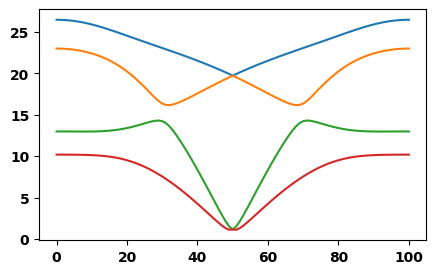

In [11]:
start = timer()
k_path = np.stack(( np.linspace(0, float(Bonds.M3_point[0])*2, 101), np.linspace(0, float(Bonds.M3_point[1])*2, 101), np.linspace(0, 0, 101) )).T
Ek = e_func(k_path)
print("spectrum. time: ", timer()-start);

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(Ek[:,0])
ax.plot(Ek[:,1])
ax.plot(Ek[:,2])
ax.plot(Ek[:,3])

plt.show()

# Second example: SSxAFO order for the Kitaev-Yao-Lee spin-orbital model

$$
H = \sum_{\langle ij\rangle_\gamma}( - \alpha\boldsymbol{S}_i\cdot \boldsymbol{S}_j + 2S_i^\gamma S_j^\gamma +\beta)
\otimes(\boldsymbol{T}_i\cdot \boldsymbol{T}_j-\beta).
$$

The calculation is similar to the spin model. Here we need to add the orbital degrees of freedom and orbital interactions.

In [12]:
h, J, alpha, beta = syp.symbols('h, J, alpha, beta', real=True); 

In [13]:
Dz = syp.Matrix([[-alpha, 0, 0],
        [0, -alpha, 0],
        [0, 0, J-alpha]]);
Mz = syp.Matrix([[1, 0, 0],
            [0, 1, 0],
            [0, 0, 1]]);

Dx = syp.Matrix([[J-alpha, 0, 0],
            [0, -alpha, 0],
            [0, 0, -alpha]]);
Mx = syp.Matrix([[1, 0, 0],
            [0, 1, 0],
            [0, 0, 1]]);

Dy = syp.Matrix([[-alpha, 0, 0],
            [0, J-alpha, 0],
            [0, 0, -alpha]]);
My = syp.Matrix([[1, 0, 0],
            [0, 1, 0],
            [0, 0, 1]]);

bond_vecs = [Bonds.delta_x, Bonds.delta_y, Bonds.delta_z]
bond_Js = [[Dx,Mx], [Dy,My], [Dz,Mz]]

To speed up the calculation, we have set the spin and orbital directions to be both along the z axis (x, y, or z are equivalent for the Kitaev interactions). 

The code is set to calculate the Hamiltonian with generic spin-orbital interactions, but the spin-only and the orbital-only terms are included as the constant $\beta$. If genric spin-only and orbital-only terms are needed, you can easily modify the spinorb_Hamiltonian() and the generalized_HPT_transform() functions.

In [14]:
## magnetic unit cell vectors
v1 = syp.Matrix([1,0,0]);
v2 = 2*syp.Matrix([syp.Integer(1)/syp.Integer(2),syp.sqrt(3)/2,0]);
v3 = syp.Matrix([0, 0, syp.Integer(1)]);

N = 4; # the SSxAFO order has 4 site in the magnetic unit cell

## spin directions (spin_theta, spin_phi, orb_theta, orb_phi) on each site
## can use symbols or numerical values
spin = syp.zeros(N,4); 
spin[0,0] = t1; spin[0,1] = 0; spin[0,2] = h1; spin[0,3] = 0; 
spin[1,0] = t2; spin[1,1] = 0; spin[1,2] = h2; spin[1,3] = 0;
spin[2,0] = t3; spin[2,1] = 0; spin[2,2] = h3; spin[2,3] = 0; 
spin[3,0] = t4; spin[3,1] = 0; spin[3,2] = h4; spin[3,3] = 0;

## position of each site in the magnetic unit cell. Make sure to use the same convention as in the Bonds.py file
atom_pos = syp.zeros(N,3);
atom_pos[0,:] = syp.zeros(1,3);
atom_pos[1,:] = Bonds.delta_x.T;
atom_pos[2,:] = Bonds.delta_x.T-Bonds.delta_z.T;
atom_pos[3,:] = 2*Bonds.delta_x.T-Bonds.delta_z.T;

In [15]:
start = timer()

## calculate all the bonds
bonds = Bonds.findBonds(atom_pos, v1,v2,v3, bond_vecs);
print("Bonds. time: ", timer()-start);


## get the symbolic Hamiltonian
H4, E4 = SW.spinorb_Hamiltonian(spin, bonds, bond_Js,beta)
print("Hamiltonian. time: ", timer()-start);

Bonds. time:  2.4316212000558153
Hamiltonian. time:  442.104574099998


In [16]:
## substitute in the numerical spin directions
## x,y,z components of each spin
ss1 = np.array([[0, 0, 1],
                [0, 0, -1],
                [0, 0, -1],
                [0, 0, 1]]);

afo1 = np.array([[0, 0, -1],
                [0, 0, 1],
                [0, 0, -1],
                [0, 0, 1]]);

sv = (ss1)
ov = (afo1)

## calculate the angles from the x,y,z components
angles = syp.zeros(N,4);
for i in range(N):
    angles[i,0] = syp.acos(sv[i,2])
    if sv[i,0]>0:
        angles[i,1] = syp.atan(sv[i,1]/sv[i,0])
    else:
        angles[i,1] = syp.atan(sv[i,1]/sv[i,0])+syp.pi
    angles[i,2] = syp.acos(ov[i,2])
    if ov[i,0]>0:
        angles[i,3] = syp.atan(ov[i,1]/ov[i,0])
    else:
        angles[i,3] = syp.atan(ov[i,1]/ov[i,0])+syp.pi

# angles = np.nan_to_num(angles)
angles = angles.subs(syp.nan, 0)
E_num = E4.subs([(t1,angles[0,0]),(p1,angles[0,1]),(h1,angles[0,2]),(g1,angles[0,3]),
                (t2,angles[1,0]),(p2,angles[1,1]),(h2,angles[1,2]),(g2,angles[1,3]),
                (t3,angles[2,0]),(p3,angles[2,1]),(h3,angles[2,2]),(g3,angles[2,3]),
                (t4,angles[3,0]),(p4,angles[3,1]),(h4,angles[3,2]),(g4,angles[3,3])])

display(E_num/(N/2))

H_num = H4.subs([(t1,angles[0,0]),(p1,angles[0,1]),(h1,angles[0,2]),(g1,angles[0,3]),
                (t2,angles[1,0]),(p2,angles[1,1]),(h2,angles[1,2]),(g2,angles[1,3]),
                (t3,angles[2,0]),(p3,angles[2,1]),(h3,angles[2,2]),(g3,angles[2,3]),
                (t4,angles[3,0]),(p4,angles[3,1]),(h4,angles[3,2]),(g4,angles[3,3])])



C:\Users\landau\AppData\Local\Temp\ipykernel_24908\3391672574.py:23: RuntimeWarning: invalid value encountered in scalar divide
  angles[i,1] = syp.atan(sv[i,1]/sv[i,0])+syp.pi
C:\Users\landau\AppData\Local\Temp\ipykernel_24908\3391672574.py:28: RuntimeWarning: invalid value encountered in scalar divide
  angles[i,3] = syp.atan(ov[i,1]/ov[i,0])+syp.pi


-0.25*J*beta - 0.0625*J - 0.25*alpha*beta - 0.0625*alpha - 0.75*beta

In [17]:
## substitute in the numerical interactions
J_num = 2.0;
a_num = 0.5;
b_num = 0.15;

print(E_num.subs([(J,J_num), (alpha,a_num), (beta, b_num)])/(N/2))
H_num2 = H_num.subs([(J,J_num), (alpha,a_num), (beta, b_num)])


## diagonalize the Hamiltonian
tau3 = np.eye(H_num.shape[0],dtype=np.complex128);
tau3[range(H_num.shape[0]//2, H_num.shape[0]), range(H_num.shape[0]//2, H_num.shape[0])] = -1;
H_func = syp.lambdify([SW.k1, SW.k2], expr2f(H_num2,10), 'numpy');

N_band = H_num.shape[0]
def  e_func(k_list):
    E_list = np.zeros((k_list.shape[0], N_band))
    for i in range(k_list.shape[0]):
        kx = k_list[i,0]; ky = k_list[i,1];
        H = H_func(kx,ky);
        cholH_dag = np.linalg.cholesky(H);
        cholH = cholH_dag.T.conj();
        E = np.linalg.eigvals(cholH@tau3@cholH_dag);
        E_list[i,:] = np.flip(np.sort(np.real(E)));
    return E_list

print(e_func(np.array([[0.01, 0.01]], dtype=float)))

-0.362500000000000
[[ 0.56572008  0.56568824  0.53734967  0.53734967  0.34641     0.346378
   0.3281125   0.3281125   0.3281125   0.3281125   0.00301815  0.00301815
  -0.00301815 -0.00301815 -0.3281125  -0.3281125  -0.3281125  -0.3281125
  -0.346378   -0.34641    -0.53734967 -0.53734967 -0.56568824 -0.56572008]]
